## 0. Crucial imports

In [25]:
import webdataset as wds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
torch.cuda.is_available()


True

# 1. Data Preparation

### 1.1 Read data to dataframme 
Reading data to pandas dataframe 
Making Dataframe searchable by 'name.png' by changing ID from integers to name of the image

In [26]:
df = pd.read_csv("Data_Entry_2017.csv")
df = df.set_index('Image Index')
print(df.head(3))


                          Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                                     
00000001_000.png            Cardiomegaly            0           1        058Y   
00000001_001.png  Cardiomegaly|Emphysema            1           1        058Y   
00000001_002.png   Cardiomegaly|Effusion            2           1        058Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00000001_000.png              M            PA                 2682     2749   
00000001_001.png              M            PA                 2894     2729   
00000001_002.png              M            PA                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00000001_000.png                        0.143  0.143          

### 1.2 Pipeline for random sample

Taking 1000 images, shuffling them, converting to PyTorchRGB tensors from 12 tar files and returning for it:
* image_data = data of each pixel
* clean_key = name of the photo (without folder name)
* label = name of the disease

In [27]:
def process_sample(sample):

    image_data = sample['png']
    full_key = sample["__key__"]
    clean_key = full_key.replace("images/", "") + ".png"
    label = df.at[clean_key, 'Finding Labels']

    return image_data, clean_key, label


url = "images/images_{001..012}.tar.gz"
dataset = (
    wds.WebDataset(url,shardshuffle=False)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process_sample)
)

for (image, key, label) in dataset:
    print(f"key={key}, image shape={image.shape}, label={label}")
    break

key=00001093_013.png, image shape=torch.Size([3, 1024, 1024]), label=Nodule


### Displaying three random images from sample

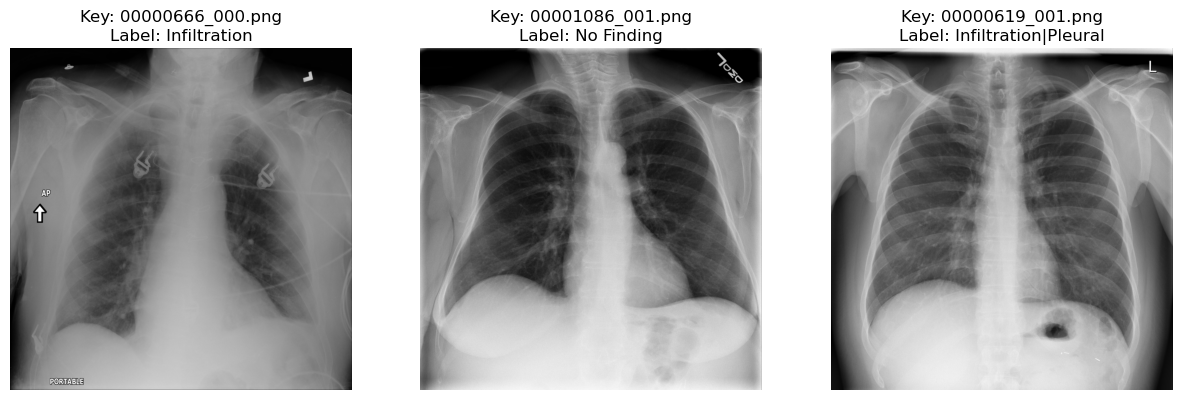

In [28]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample_iter = iter(dataset)

for i in range(3):
    image_tensor, key, label = next(sample_iter)
    img = image_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(f"Key: {key}\nLabel: {label[:20]}")
    axes[i].axis('off')

plt.show()

## Shuffling csv file for randomness

In [29]:
shuffled_df = df.sample(frac=1)
print(shuffled_df.head(2))

                 Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                            
00018186_001.png     No Finding            1       18186        042Y   
00001301_001.png   Infiltration            1        1301        056Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00018186_001.png              M            AP                 2500     2048   
00001301_001.png              F            AP                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00018186_001.png                        0.168  0.168          NaN  
00001301_001.png                        0.168  0.168          NaN  


## Splitting data into training and validation

In [30]:
population_size = len(df)
train_split = int(0.8*population_size)

train_df = shuffled_df[:train_split]
val_df = shuffled_df[train_split:]

val_df

,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
Image Index,,,,,,,,,,,
00020129_002.png,Infiltration,2,20129,045Y,M,AP,3056,2544,0.139000,0.139000,NaN
00027305_000.png,No Finding,0,27305,043Y,F,PA,2620,2600,0.143000,0.143000,NaN
00005684_005.png,No Finding,5,5684,026Y,M,AP,2500,2048,0.171000,0.171000,NaN
00029105_013.png,No Finding,13,29105,056Y,F,PA,2020,2016,0.194311,0.194311,NaN
00008089_000.png,No Finding,0,8089,056Y,M,PA,2500,2048,0.168000,0.168000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
00001321_000.png,No Finding,0,1321,045Y,F,PA,2736,2828,0.143000,0.143000,NaN
00017450_000.png,No Finding,0,17450,043Y,F,PA,2992,2991,0.143000,0.143000,NaN
00006304_006.png,Cardiomegaly|Consolidation|Edema|Infiltration,6,6304,067Y,F,AP,2500,2048,0.168000,0.168000,NaN


In [31]:
len(shuffled_df), len(train_df), len(val_df)

(112120, 89696, 22424)